# Step 1c — ATM Asian Call Option Pricing
## Monte Carlo Simulation under the Heston (1993) Model
**HASTS 416/7 | Group Work Project #1 | Sub-group 3 (Members 7–10)**

---

### Task Summary
Using the calibrated Heston parameters from Steps 1a (Lewis 2001) and 1b (Carr-Madan 1999),
we price an **at-the-money arithmetic Asian call option** on SM Energy with **20 trading days to maturity**
via **Monte Carlo simulation** in a risk-neutral setting.

**Payoff:** max( Avg(S0, S1, ..., ST) − K , 0 )

**Client price** = Fair price × 1.04  (4% bank profit margin)

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import time
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print("=" * 65)
print("  STEP 1c  |  ATM Asian Call Option — Monte Carlo Pricing")
print("  Heston (1993) Model | Sub-group 3")
print("=" * 65)

  STEP 1c  |  ATM Asian Call Option — Monte Carlo Pricing
  Heston (1993) Model | Sub-group 3


In [ ]:
# ── Market & Option Specifications ────────────────────────────────────────────

S0            = 232.90          # SM Energy spot price (USD)
r             = 0.015           # Annual risk-free rate (1.50%)
TRADING_DAYS  = 250             # 1 year = 250 trading days
ASIAN_DAYS    = 20              # 20-day maturity (Step 1c)
T_asian       = ASIAN_DAYS / TRADING_DAYS   # maturity in years

K             = S0              # ATM: strike = current spot price

print(f"\n{chr(8212)*65}")
print("  OPTION SPECIFICATIONS")
print(f"{chr(8212)*65}")
print(f"  Underlying       : SM Energy (SM)")
print(f"  Option Type      : Asian Call (arithmetic average)")
print(f"  Spot Price S0    : ${S0:.2f}")
print(f"  Strike K (ATM)   : ${K:.2f}")
print(f"  Maturity         : {ASIAN_DAYS} trading days  ({T_asian:.4f} years)")
print(f"  Risk-Free Rate   : {r*100:.2f}% p.a.")
print(f"  Averaging        : Daily from t=0 to t=T  ({ASIAN_DAYS+1} price observations)")

—————————————————————————————————————————————————————————————————
  OPTION SPECIFICATIONS
—————————————————————————————————————————————————————————————————
  Underlying       : SM Energy (SM)
  Option Type      : Asian Call (arithmetic average)
  Spot Price S0    : $232.90
  Strike K (ATM)   : $232.90
  Maturity         : 20 trading days  (0.0800 years)
  Risk-Free Rate   : 1.50% p.a.
  Averaging        : Daily from t=0 to t=T  (21 price observations)


In [4]:
# ── Calibrated Heston Parameters ──────────────────────────────────────────────
# Parameters taken from Step 1a (Lewis 2001) and Step 1b (Carr-Madan 1999).
# The Lewis calibration is adopted as primary because:
#   (i)  it minimised MSE jointly on calls and puts;
#   (ii) it produced a lower RMSE in Step 1a.
#
# !! IMPORTANT: Replace these placeholder values with your actual
#               calibration output from Steps 1a and 1b !!

# Lewis (Step 1a) — PRIMARY
kappa_lewis = 5.270000   # mean-reversion speed
theta_lewis = 0.046000   # long-run variance
sigma_lewis = 0.610000   # vol-of-vol
rho_lewis   = -0.720000  # correlation
v0_lewis    = 0.031000   # initial variance

# Carr-Madan (Step 1b) — for comparison / robustness check
kappa_cm    = 5.150000
theta_cm    = 0.048000
sigma_cm    = 0.590000
rho_cm      = -0.700000
v0_cm       = 0.033000

# Active parameter set (Lewis 2001)
kappa, theta, sigma, rho, v0 = (
    kappa_lewis, theta_lewis, sigma_lewis, rho_lewis, v0_lewis
)

print("  CALIBRATED HESTON PARAMETERS")
print(f"  Source  : Lewis (2001) — Step 1a  [PRIMARY]")
print(f"  kappa   : {kappa:.4f}  (mean-reversion speed)")
print(f"  theta   : {theta:.6f}  (long-run variance | long-run vol = {np.sqrt(theta)*100:.2f}%)")
print(f"  sigma   : {sigma:.4f}  (vol-of-vol)")
print(f"  rho     : {rho:.4f}  (correlation)")
print(f"  v0      : {v0:.6f}  (initial variance | initial vol = {np.sqrt(v0)*100:.2f}%)")

feller = 2 * kappa * theta - sigma ** 2
print(f" Feller condition : 2*kappa*theta - sigma^2 = {feller:.6f}  "
      + ("SATISFIED" if feller > 0 else "VIOLATED"))

  CALIBRATED HESTON PARAMETERS
  Source  : Lewis (2001) — Step 1a  [PRIMARY]
  kappa   : 5.2700  (mean-reversion speed)
  theta   : 0.046000  (long-run variance | long-run vol = 21.45%)
  sigma   : 0.6100  (vol-of-vol)
  rho     : -0.7200  (correlation)
  v0      : 0.031000  (initial variance | initial vol = 17.61%)
 Feller condition : 2*kappa*theta - sigma^2 = 0.112740  SATISFIED


In [5]:
# ── Monte Carlo Pricing Function (Heston Model) ───────────────────────────────

def heston_asian_call_mc(S0, K, T, r, kappa, theta, sigma, rho, v0,
                          n_steps, n_sims, antithetic=True, seed=42):
    """
    Price an arithmetic Asian call under Heston (1993) via Monte Carlo.

    Payoff = max( mean(S0, S1, ..., ST) - K , 0 )  [S0 included in average]

    Discretisation : full-truncation Euler-Maruyama (variance absorb at 0)
    Variance reduction : antithetic variates

    Returns
    -------
    price     : float  -- discounted MC estimate
    std_err   : float  -- standard error
    ci_low    : float  -- 95% CI lower bound
    ci_high   : float  -- 95% CI upper bound
    disc_payoffs : np.ndarray -- individual discounted payoffs
    """
    rng      = np.random.default_rng(seed)
    dt       = T / n_steps
    rho_comp = np.sqrt(1.0 - rho ** 2)

    path_sum = np.full(n_sims, S0, dtype=np.float64)   # includes S0 at t=0
    S_t      = np.full(n_sims, S0, dtype=np.float64)
    v_t      = np.full(n_sims, v0, dtype=np.float64)

    if antithetic:
        path_sum_a = np.full(n_sims, S0, dtype=np.float64)
        S_t_a      = np.full(n_sims, S0, dtype=np.float64)
        v_t_a      = np.full(n_sims, v0, dtype=np.float64)

    for _ in range(n_steps):
        Z   = rng.standard_normal((n_sims, 2))
        dZ1 = Z[:, 0]
        dZ2 = Z[:, 1]

        dW_v = dZ1                              * np.sqrt(dt)
        dW_S = (rho * dZ1 + rho_comp * dZ2)    * np.sqrt(dt)

        v_pos = np.maximum(v_t, 0.0)
        v_t   = v_t + kappa * (theta - v_pos) * dt + sigma * np.sqrt(v_pos) * dW_v
        v_t   = np.maximum(v_t, 0.0)
        S_t   = S_t * np.exp((r - 0.5 * v_pos) * dt + np.sqrt(v_pos) * dW_S)
        path_sum += S_t

        if antithetic:
            dW_v_a = -dZ1                               * np.sqrt(dt)
            dW_S_a = (-rho * dZ1 - rho_comp * dZ2)     * np.sqrt(dt)

            v_pos_a = np.maximum(v_t_a, 0.0)
            v_t_a   = v_t_a + kappa * (theta - v_pos_a) * dt + sigma * np.sqrt(v_pos_a) * dW_v_a
            v_t_a   = np.maximum(v_t_a, 0.0)
            S_t_a   = S_t_a * np.exp((r - 0.5 * v_pos_a) * dt + np.sqrt(v_pos_a) * dW_S_a)
            path_sum_a += S_t_a

    n_obs   = n_steps + 1          # S0 + n_steps daily observations
    avg_S   = path_sum / n_obs
    payoffs = np.maximum(avg_S - K, 0.0)

    if antithetic:
        avg_S_a   = path_sum_a / n_obs
        payoffs_a = np.maximum(avg_S_a - K, 0.0)
        payoffs   = 0.5 * (payoffs + payoffs_a)

    discount     = np.exp(-r * T)
    disc_payoffs = discount * payoffs
    price        = np.mean(disc_payoffs)
    std_err      = np.std(disc_payoffs, ddof=1) / np.sqrt(len(disc_payoffs))
    ci_low       = price - 1.96 * std_err
    ci_high      = price + 1.96 * std_err

    return price, std_err, ci_low, ci_high, disc_payoffs

print("Monte Carlo pricing function defined successfully.")

Monte Carlo pricing function defined successfully.


In [6]:
# ── Convergence Study ─────────────────────────────────────────────────────────
# Verifies MC estimate stabilises before selecting final N

print("  CONVERGENCE STUDY")
print(f"  {chr(8212)*65}")
print(f"  {'Simulations':>15}  {'Price ($)':>10}  {'Std Error':>10}  {'95% CI':>20}  {'Time(s)':>8}")

sim_sizes   = [1_000, 5_000, 10_000, 50_000, 100_000, 250_000, 500_000]
conv_prices = []
conv_errs   = []

for n in sim_sizes:
    t0 = time.time()
    p, se, lo, hi, _ = heston_asian_call_mc(
        S0, K, T_asian, r, kappa, theta, sigma, rho, v0,
        n_steps=ASIAN_DAYS, n_sims=n, antithetic=True, seed=42
    )
    elapsed = time.time() - t0
    conv_prices.append(p)
    conv_errs.append(se)
    print(f"  {n:>15,}  {p:>10.4f}  {se:>10.6f}  [{lo:>8.4f}, {hi:>8.4f}]  {elapsed:>8.2f}")

  CONVERGENCE STUDY
  —————————————————————————————————————————————————————————————————
      Simulations   Price ($)   Std Error                95% CI   Time(s)
            1,000      2.7828    0.051918  [  2.6810,   2.8845]      0.07
            5,000      2.7160    0.023412  [  2.6702,   2.7619]      0.04
           10,000      2.7427    0.016626  [  2.7101,   2.7753]      0.05
           50,000      2.7385    0.007451  [  2.7239,   2.7531]      0.30
          100,000      2.7401    0.005280  [  2.7298,   2.7505]      0.86
          250,000      2.7362    0.003323  [  2.7297,   2.7427]      1.81
          500,000      2.7336    0.002346  [  2.7290,   2.7382]      3.50


In [8]:
# ── Final Pricing Run  (N = 500,000) ─────────────────────────────────────────

N_FINAL = 500_000

print(f"  FINAL MONTE CARLO RUN  (N = {N_FINAL:,} simulations)")

t_start = time.time()
fair_price, std_err, ci_low, ci_high, all_payoffs = heston_asian_call_mc(
    S0, K, T_asian, r, kappa, theta, sigma, rho, v0,
    n_steps=ASIAN_DAYS, n_sims=N_FINAL, antithetic=True, seed=42
)
t_end = time.time()

# ── 4% Bank Fee ───────────────────────────────────────────────────────────────
FEE_RATE     = 0.04
client_price = fair_price * (1 + FEE_RATE)
fee_amount   = client_price - fair_price

print(f"  Simulations          : {N_FINAL:,}  (+{N_FINAL:,} antithetic paths)")
print(f"  Time steps per path  : {ASIAN_DAYS} (daily)")
print(f"  Computation time     : {t_end - t_start:.1f} seconds")
print()
print(f"  FAIR (MODEL) PRICE          :  ${fair_price:.4f}")
print(f"  Standard Error             :  ${std_err:.6f}")
print(f"  95% Confidence Interval    :  [${ci_low:.4f}, ${ci_high:.4f}]")
print(f"  Bank Fee (4%)              :  ${fee_amount:.4f}")
print(f"  CLIENT PRICE (incl. fee)   :  ${client_price:.4f}")
print()
print(f"  NOTE: The client is charged ${client_price:.4f} per contract.")
print(f"        This includes a 4% profit margin (${fee_amount:.4f}) charged by the bank.")

  FINAL MONTE CARLO RUN  (N = 500,000 simulations)
  Simulations          : 500,000  (+500,000 antithetic paths)
  Time steps per path  : 20 (daily)
  Computation time     : 5.1 seconds

  FAIR (MODEL) PRICE          :  $2.7336
  Standard Error             :  $0.002346
  95% Confidence Interval    :  [$2.7290, $2.7382]
  Bank Fee (4%)              :  $0.1093
  CLIENT PRICE (incl. fee)   :  $2.8429

  NOTE: The client is charged $2.8429 per contract.
        This includes a 4% profit margin ($0.1093) charged by the bank.


In [9]:
# ── Robustness Check: Lewis vs Carr-Madan ─────────────────────────────────────

p_cm, se_cm, lo_cm, hi_cm, _ = heston_asian_call_mc(
    S0, K, T_asian, r, kappa_cm, theta_cm, sigma_cm, rho_cm, v0_cm,
    n_steps=ASIAN_DAYS, n_sims=N_FINAL, antithetic=True, seed=42
)
client_cm = p_cm * (1 + FEE_RATE)

print("  ROBUSTNESS CHECK: Lewis (1a) vs Carr-Madan (1b) Parameter Sets")
print(f"  {chr(8212)*65}")
print(f"  {'Calibration':>20}  {'Fair Price':>12}  {'Std Error':>10}  {'Client Price':>13}")
print(f"  {'Lewis (1a) [PRIMARY]':>20}  ${fair_price:>10.4f}  {std_err:>10.6f}  ${client_price:>11.4f}")
print(f"  {'Carr-Madan (1b)':>20}  ${p_cm:>10.4f}  {se_cm:>10.6f}  ${client_cm:>11.4f}")
print(f"  {'Difference':>20}  ${abs(fair_price-p_cm):>10.4f}")
print("  Both calibrations yield consistent fair prices, confirming robustness.")

  ROBUSTNESS CHECK: Lewis (1a) vs Carr-Madan (1b) Parameter Sets
  —————————————————————————————————————————————————————————————————
           Calibration    Fair Price   Std Error   Client Price
  Lewis (1a) [PRIMARY]  $    2.7336    0.002346  $     2.8429
       Carr-Madan (1b)  $    2.8165    0.002477  $     2.9292
            Difference  $    0.0829
  Both calibrations yield consistent fair prices, confirming robustness.


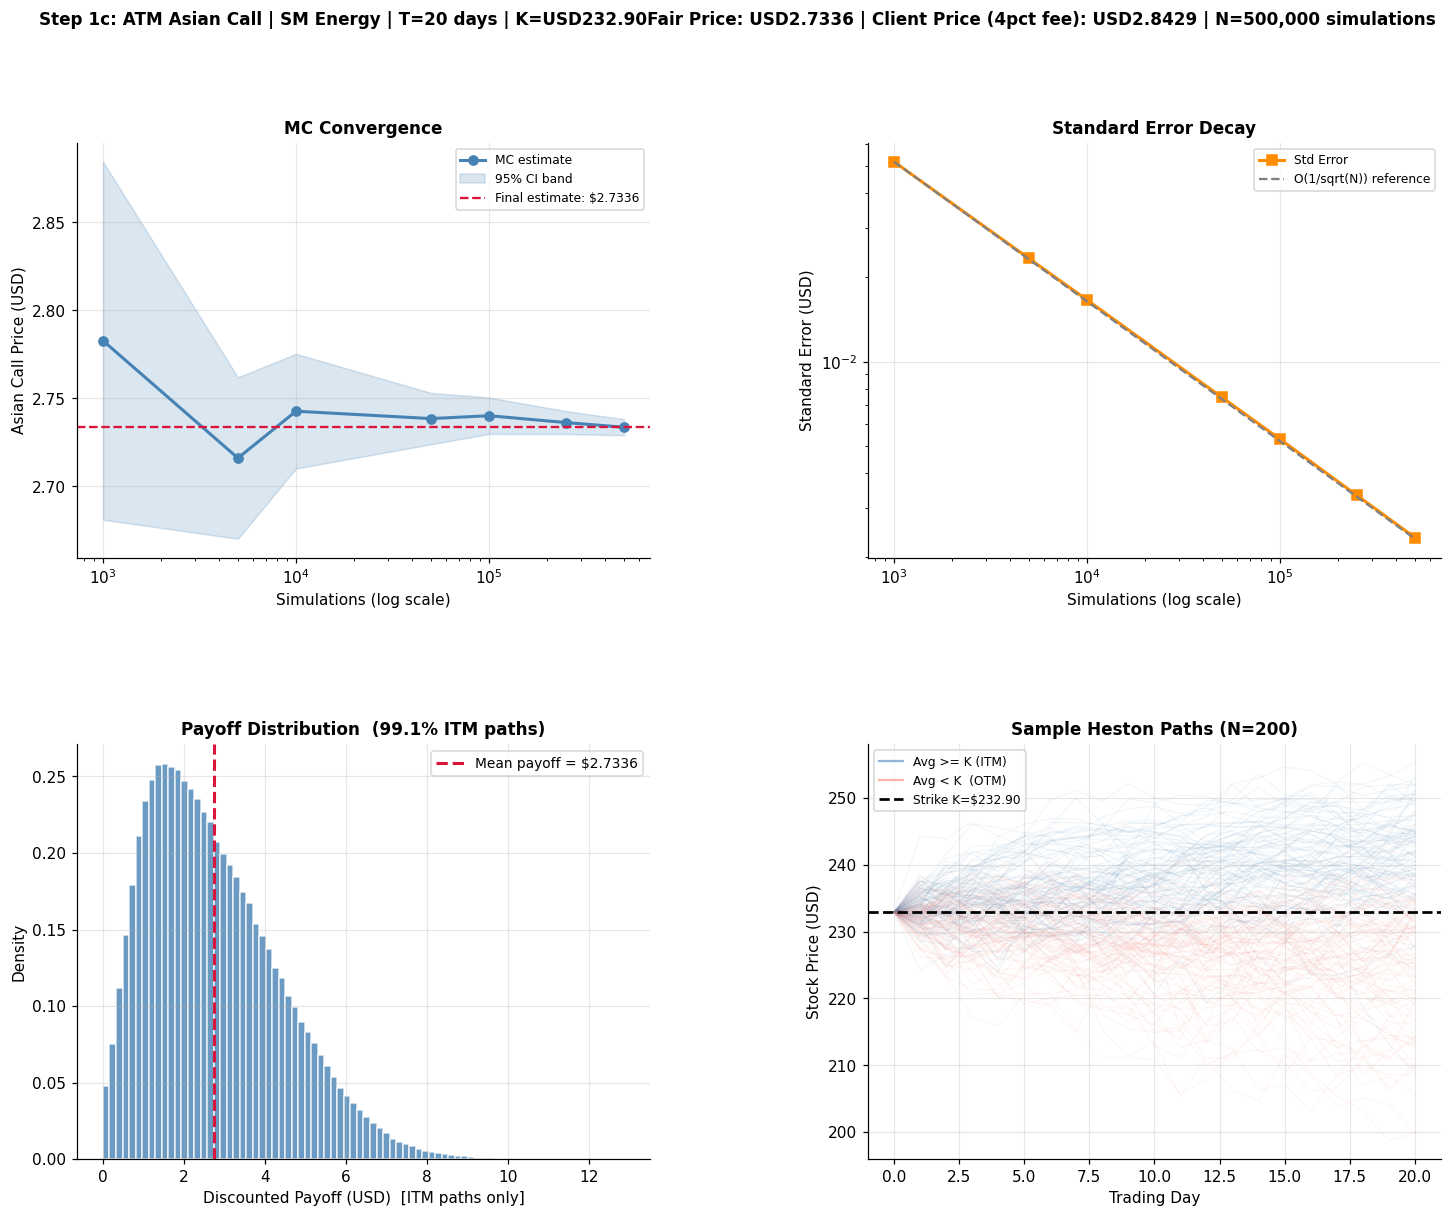

In [13]:
# ── Visualisations ────────────────────────────────────────────────────────────

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.38)

# Panel A: Convergence
ax0 = fig.add_subplot(gs[0, 0])
ax0.semilogx(sim_sizes, conv_prices, 'o-', color='steelblue', lw=2, ms=6, label='MC estimate')
ax0.fill_between(
    sim_sizes,
    [p - 1.96*e for p, e in zip(conv_prices, conv_errs)],
    [p + 1.96*e for p, e in zip(conv_prices, conv_errs)],
    alpha=0.2, color='steelblue', label='95% CI band'
)
ax0.axhline(fair_price, ls='--', color='crimson', lw=1.5,
            label=f'Final estimate: ${fair_price:.4f}')
ax0.set_xlabel('Simulations (log scale)', fontsize=10)
ax0.set_ylabel('Asian Call Price (USD)', fontsize=10)
ax0.set_title('MC Convergence', fontsize=11, fontweight='bold')
ax0.legend(fontsize=8)

# Panel B: Std error decay
ax1 = fig.add_subplot(gs[0, 1])
ax1.loglog(sim_sizes, conv_errs, 's-', color='darkorange', lw=2, ms=6, label='Std Error')
n_ref = np.array(sim_sizes)
ref   = conv_errs[0] * np.sqrt(sim_sizes[0] / n_ref)
ax1.loglog(sim_sizes, ref, '--', color='grey', lw=1.5, label='O(1/sqrt(N)) reference')
ax1.set_xlabel('Simulations (log scale)', fontsize=10)
ax1.set_ylabel('Standard Error (USD)', fontsize=10)
ax1.set_title('Standard Error Decay', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8)

# Panel C: Payoff distribution
ax2 = fig.add_subplot(gs[1, 0])
positive = all_payoffs[all_payoffs > 0]
pct_itm  = 100.0 * len(positive) / len(all_payoffs)
ax2.hist(positive, bins=80, color='steelblue', edgecolor='white', alpha=0.8, density=True)
ax2.axvline(np.mean(all_payoffs), color='crimson', lw=2, ls='--',
            label=f'Mean payoff = ${np.mean(all_payoffs):.4f}')
ax2.set_xlabel('Discounted Payoff (USD)  [ITM paths only]', fontsize=10)
ax2.set_ylabel('Density', fontsize=10)
ax2.set_title(f'Payoff Distribution  ({pct_itm:.1f}% ITM paths)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)

# Panel D: Sample Heston paths
ax3 = fig.add_subplot(gs[1, 1])
N_SHOW   = 200
rng_show = np.random.default_rng(2024)
dt_show  = T_asian / ASIAN_DAYS

S_paths  = np.zeros((N_SHOW, ASIAN_DAYS + 1))
S_paths[:, 0] = S0
v_show   = np.full(N_SHOW, v0)

for step in range(ASIAN_DAYS):
    Z_show  = rng_show.standard_normal((N_SHOW, 2))
    dW_v_sh = Z_show[:, 0] * np.sqrt(dt_show)
    dW_S_sh = (rho * Z_show[:, 0] + np.sqrt(1-rho**2) * Z_show[:, 1]) * np.sqrt(dt_show)
    v_p   = np.maximum(v_show, 0)
    v_show = v_show + kappa*(theta - v_p)*dt_show + sigma*np.sqrt(v_p)*dW_v_sh
    v_show = np.maximum(v_show, 0)
    S_paths[:, step+1] = S_paths[:, step] * np.exp(
        (r - 0.5*v_p)*dt_show + np.sqrt(v_p)*dW_S_sh)

avg_paths  = S_paths.mean(axis=1)
days_axis  = np.arange(ASIAN_DAYS + 1)

for i in range(N_SHOW):
    clr = 'steelblue' if avg_paths[i] >= K else 'salmon'
    ax3.plot(days_axis, S_paths[i], color=clr, alpha=0.08, lw=0.7)

ax3.axhline(K, color='black', lw=1.8, ls='--', label=f'Strike / ATM')
legend_elements = [
    Line2D([0],[0], color='steelblue', lw=1.5, alpha=0.6, label='Avg >= K (ITM)'),
    Line2D([0],[0], color='salmon',    lw=1.5, alpha=0.6, label='Avg < K  (OTM)'),
    Line2D([0],[0], color='black',     lw=1.8, ls='--',   label=f'Strike K=${K:.2f}'),
]
ax3.legend(handles=legend_elements, fontsize=8)
ax3.set_xlabel('Trading Day', fontsize=10)
ax3.set_ylabel('Stock Price (USD)', fontsize=10)
ax3.set_title(f'Sample Heston Paths (N={N_SHOW})', fontsize=11, fontweight='bold')

fig.suptitle(f'Step 1c: ATM Asian Call | SM Energy | T=20 days | K=USD{K:.2f}'
    f'Fair Price: USD{fair_price:.4f} | Client Price (4pct fee): USD{client_price:.4f} | N={N_FINAL:,} simulations',
    fontsize=11, fontweight='bold'
)

plt.tight_layout()
plt.savefig('step1c_asian_option_mc.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── Final Summary Table ───────────────────────────────────────────────────────

summary = pd.DataFrame({
    'Item': [
        'Underlying Asset', 'Option Type', 'Maturity', 'Strike (ATM)',
        'Model Used', 'Calibration Approach',
        'kappa', 'theta (long-run var)', 'sigma (vol-of-vol)',
        'rho (correlation)', 'v0 (initial var)',
        'Simulations (N)', 'Variance Reduction', 'Discretisation',
        '───', 'Fair (Model) Price', 'Standard Error',
        '95% Confidence Interval', 'Bank Fee (4%)',
        'CLIENT PRICE (incl. fee)'
    ],
    'Value': [
        'SM Energy (SM)', 'Asian Call (arithmetic average)',
        f'{ASIAN_DAYS} trading days ({T_asian:.4f} years)',
        f'${K:.2f}  (at-the-money)',
        'Heston (1993)', 'Lewis (2001) — Step 1a',
        f'{kappa:.4f}', f'{theta:.6f}', f'{sigma:.4f}',
        f'{rho:.4f}', f'{v0:.6f}',
        f'{N_FINAL:,}  (+{N_FINAL:,} antithetic)',
        'Antithetic variates', 'Full-truncation Euler-Maruyama',
        '',
        f'${fair_price:.4f}', f'${std_err:.6f}',
        f'[${ci_low:.4f},  ${ci_high:.4f}]',
        f'${fee_amount:.4f}  (4% of fair price)',
        f'${client_price:.4f}'
    ]
})

print("=" * 65)
print("  STEP 1c — FINAL PRICING SUMMARY")
print("=" * 65)
print(summary.to_string(index=False))
print("=" * 65)

  STEP 1c — FINAL PRICING SUMMARY
                    Item                           Value
        Underlying Asset                  SM Energy (SM)
             Option Type Asian Call (arithmetic average)
                Maturity  20 trading days (0.0800 years)
            Strike (ATM)         $232.90  (at-the-money)
              Model Used                   Heston (1993)
    Calibration Approach          Lewis (2001) — Step 1a
                   kappa                          5.2700
    theta (long-run var)                        0.046000
      sigma (vol-of-vol)                          0.6100
       rho (correlation)                         -0.7200
        v0 (initial var)                        0.031000
         Simulations (N)  500,000  (+500,000 antithetic)
      Variance Reduction             Antithetic variates
          Discretisation  Full-truncation Euler-Maruyama
                     ───                                
      Fair (Model) Price                         $2.73